In [6]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
    --------------------------------------- 1.0/44.0 MB 5.7 MB/s eta 0:00:08
   - -------------------------------------- 1.8/44.0 MB 4.6 MB/s eta 0:00:10
   -- ------------------------------------- 2.6/44.0 MB 4.4 MB/s eta 0:00:10
   --- ------------------------------------ 3.4/44.0 MB 4.2 MB/s eta 0:00:10
   --- ------------------------------------ 4.2/44.0 MB 4.1 MB/s eta 0:00:10
   ---- ----------------------------------- 5.0/44.0 MB 4.0 MB/s eta 0:00:10
   ----- ---------------------------------- 6.0/44.0 MB 4.1 MB/s eta 0:00:10
   ------ --------------------------------- 6.8/44.0 MB 4.1 MB/s eta 0:00:10
   ------ --------------------------------- 7.6/44.0 MB 4.0 MB/s eta 0:00:10
   ------- -------------------------------- 8.1/44.0 MB 3.9 MB/s eta 0:00:10
   -------- ------------------------------- 9.2/44.0 MB 4.0 MB/s eta 0:00:09
   --

In [8]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 5.0 MB/s eta 0:00:02
   ------- -------------------------------- 1.8/9.5 MB 4.5 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.5 MB 4.0 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 3.9 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.5 MB 4.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.5 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.5 MB 4.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.5 MB 3.9 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 4.0 MB/s eta 0:00:01
   --------------

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random

random.seed(42)
%matplotlib inline


In [10]:
# EDIT THIS PATH to match your downloaded dataset location
DATA_DIR = r"casting_data/train"   # folder containing ok_front/ and def_front/

N_SAMPLES = 25   # how many images per class to use (keep small for a mini project)

ok_paths  = sorted(glob.glob(os.path.join(DATA_DIR, "ok_front", "*.jpeg")) +
                    glob.glob(os.path.join(DATA_DIR, "ok_front", "*.jpg")) +
                    glob.glob(os.path.join(DATA_DIR, "ok_front", "*.png")))
def_paths = sorted(glob.glob(os.path.join(DATA_DIR, "def_front", "*.jpeg")) +
                    glob.glob(os.path.join(DATA_DIR, "def_front", "*.jpg")) +
                    glob.glob(os.path.join(DATA_DIR, "def_front", "*.png")))

random.shuffle(ok_paths)
random.shuffle(def_paths)
ok_paths  = ok_paths[:N_SAMPLES]
def_paths = def_paths[:N_SAMPLES]

print(f"Loaded {len(ok_paths)} ok_front images and {len(def_paths)} def_front images")
assert len(ok_paths) > 0 and len(def_paths) > 0, "No images found — check DATA_DIR path!"


Loaded 25 ok_front images and 25 def_front images


In [11]:
def extract_shape_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold -> binary mask separating part from background
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
    x, y, w, h = cv2.boundingRect(c)
    hull = cv2.convexHull(c)
    hull_area = cv2.contourArea(hull)

    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    solidity = area / hull_area if hull_area > 0 else 0
    aspect_ratio = w / h if h > 0 else 0
    extent = area / (w * h) if (w * h) > 0 else 0

    return {
        "img": img, "gray": gray, "thresh": thresh, "contour": c,
        "area": area, "perimeter": perimeter,
        "circularity": circularity, "solidity": solidity,
        "aspect_ratio": aspect_ratio, "extent": extent,
    }


In [12]:
results = []

for p in ok_paths:
    f = extract_shape_features(p)
    if f:
        results.append({"path": p, "label": "ok", **f})

for p in def_paths:
    f = extract_shape_features(p)
    if f:
        results.append({"path": p, "label": "defective", **f})

print(f"Extracted features for {len(results)} images")


Extracted features for 50 images


In [13]:
ok_circ = [r["circularity"] for r in results if r["label"] == "ok"]
ok_sol  = [r["solidity"]    for r in results if r["label"] == "ok"]

circ_thresh = np.mean(ok_circ) - 1.5 * np.std(ok_circ)
sol_thresh  = np.mean(ok_sol)  - 1.5 * np.std(ok_sol)

print(f"OK parts -> circularity mean={np.mean(ok_circ):.3f} std={np.std(ok_circ):.3f}")
print(f"OK parts -> solidity    mean={np.mean(ok_sol):.3f} std={np.std(ok_sol):.3f}")
print(f"Decision thresholds -> circularity < {circ_thresh:.3f} OR solidity < {sol_thresh:.3f} => FLAG defective")

def classify(r):
    if r["circularity"] < circ_thresh or r["solidity"] < sol_thresh:
        return "defective"
    return "ok"

for r in results:
    r["predicted"] = classify(r)


OK parts -> circularity mean=0.785 std=0.000
OK parts -> solidity    mean=1.000 std=0.000
Decision thresholds -> circularity < 0.785 OR solidity < 1.000 => FLAG defective


In [14]:
correct = sum(1 for r in results if r["predicted"] == r["label"])
accuracy = correct / len(results)
print(f"Accuracy on sampled set: {accuracy*100:.1f}%  ({correct}/{len(results)})")

# simple confusion matrix
tp = sum(1 for r in results if r["label"]=="defective" and r["predicted"]=="defective")
fn = sum(1 for r in results if r["label"]=="defective" and r["predicted"]=="ok")
tn = sum(1 for r in results if r["label"]=="ok" and r["predicted"]=="ok")
fp = sum(1 for r in results if r["label"]=="ok" and r["predicted"]=="defective")

print("\nConfusion matrix:")
print(f"                 predicted ok   predicted defective")
print(f"actual ok            {tn:5d}            {fp:5d}")
print(f"actual defective     {fn:5d}            {tp:5d}")


Accuracy on sampled set: 52.0%  (26/50)

Confusion matrix:
                 predicted ok   predicted defective
actual ok               25                0
actual defective        24                1


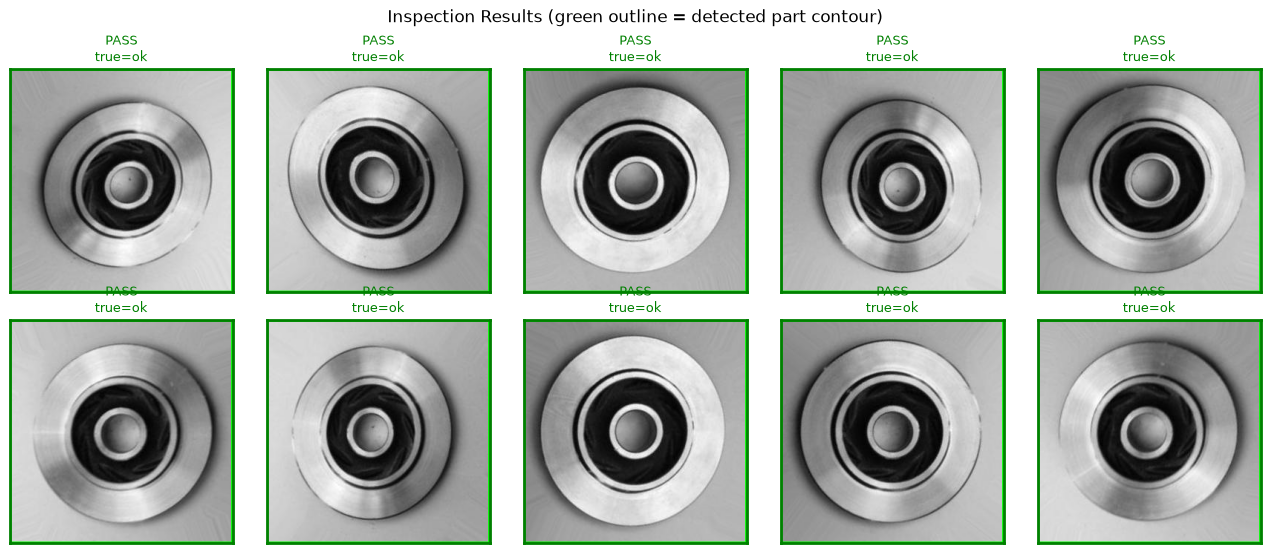

In [15]:
def show_grid(items, cols=5, title=""):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.6, rows*2.8))
    axes = np.array(axes).reshape(-1)

    for ax, r in zip(axes, items):
        vis = r["img"].copy()
        cv2.drawContours(vis, [r["contour"]], -1, (0, 255, 0), 2)
        vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
        ax.imshow(vis_rgb)
        correct = r["predicted"] == r["label"]
        tag = "PASS" if r["predicted"] == "ok" else "FAIL"
        color = "green" if correct else "red"
        ax.set_title(f"{tag}\ntrue={r['label']}", fontsize=9, color=color)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        ax.set_xticks([]); ax.set_yticks([])

    for ax in axes[len(items):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

sample_to_show = results[:10]  # first 10 (mix of ok/defective as loaded)
show_grid(sample_to_show, cols=5, title="Inspection Results (green outline = detected part contour)")


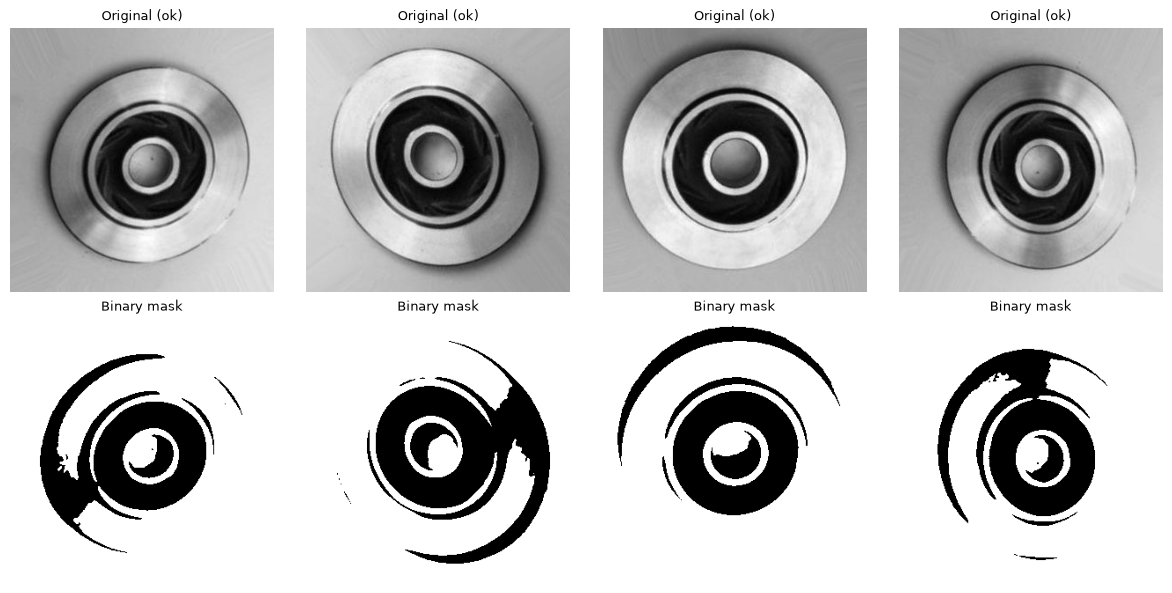

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, r in enumerate(results[:4]):
    axes[0, i].imshow(cv2.cvtColor(r["img"], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Original ({r['label']})", fontsize=9)
    axes[0, i].axis("off")
    axes[1, i].imshow(r["thresh"], cmap="gray")
    axes[1, i].set_title("Binary mask", fontsize=9)
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()
